## Clinical scores
Latest version of this notebook is in `/n/groups/marks/projects/indels_human/anon/proteingym/clinical_benchmark_notebooks/clinical_subs_processing.ipynb`

This notebook loads scores from all the different models, and processes these scores into the merged format downloadable from the proteingym website. 

To recompute the stats using the downloaded file, use get_clinical_stats.ipynb

In [1]:
from glob import glob
import os

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm
tqdm.pandas()

pd.set_option('display.max_columns', None)

In [11]:
os.makedirs(f"{ROOT}/Clinical_datasets/notebooks/processed_data/clinvar_20250226/")

In [12]:
ROOT = "/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym/"  # Change this to the root of the repo
# Inputs
model_scores_folder = f"{ROOT}/model_scores/zero_shot_clinical_substitutions/"
clinvar_variants = f"{ROOT}/Clinical_datasets/clinvar_proteingym_20230611.GRCh38_filter_isoform_clean.csv"
clinvar_mapping = f"{ROOT}/Clinical_datasets/clinical_substitutions_mapping_by_refseq_filter_isoform.csv"
dbnsfp_output = f"{ROOT}/Clinical_datasets/dbnsfp_44a/clinvar_proteingym_20230611.GRCh38_filter_isoform_clean.dbSNFP_out.txt"

# Outputs
dbnsfp_clean_file = f"{ROOT}/Clinical_datasets/notebooks/processed_data/clinvar_20250226/dbnsfp_clean_clinvar_proteingym_20230611.GRCh38_filter_isoform_clean.csv"
merged_zero_shot_clinical = f"{ROOT}/Clinical_datasets/notebooks/processed_data/clinvar_20250226/baseline_models_clinvar_merged.csv"
merged_models_file = f"{ROOT}/Clinical_datasets/notebooks/processed_data/clinvar_20250226/all_models_clinvar_proteingym_20230611.GRCh38_filter_isoform_clean.csv"
merged_models_deduplicated = f"{ROOT}/Clinical_datasets/notebooks/processed_data/clinvar_20250226/all_models_deduplicated_scores_clinvar_proteingym_20230611.GRCh38_filter_isoform_clean.csv"
clinical_scores_file = f"{ROOT}/Clinical_datasets/2025_02_26_clinical_substitutions_scores.csv"
clinical_rankings_file = f"{ROOT}/Clinical_datasets/2025_02_26_clinical_substitutions_AUC_rankings.csv"

## Constants

In [3]:
# All of these are folders in ProteinGym/model_scores/zero_shot_clinical_substitutions
model_cols = {
    "ESM1b": "esm1b_t33_650M_UR50S",
    "EVE": "evol_indices", 
    "GEMME": "GEMME_score", 
    "TranceptEVE/TranceptEVE_L": "avg_score",
}
new_model_cols = {
    "ESM1b": "ESM1b",
    "EVE": "EVE",
    "TranceptEVE/TranceptEVE_L": "TranceptEVE",
    "GEMME": "GEMME",
}


db_nsfp_models = [
    # New after reading review paper:
    "MetaRNN_score",
    "SIFT4G_score",
    # New ones:
    "REVEL_score",
    "BayesDel_addAF_score",  # Could also use noAF
    "BayesDel_noAF_score",
    "PrimateAI_score",
    "ClinPred_score", 
    "VARITY_R_LOO_score",
    "VARITY_ER_LOO_score",
    "gMVP_score",
    "VEST4_score",
    # Previous
    "CADD_phred",  # Could also use CADD_RAW
    "Polyphen2_HDIV_score", 
    "Polyphen2_HVAR_score",
    "DEOGEN2_score",
    "SIFT_score",
    "PROVEAN_score",
    "MutationAssessor_score",
    "MPC_score",
    "MutPred_score",
    "PrimateAI_score",
    "LIST-S2_score",
    "DANN_score",
    "LRT_score",
    "FATHMM_score",
    "MutationTaster_converted_rankscore",
]
score_directionality_flip = ["LRT_score", "FATHMM_score", "SIFT_score", "PROVEAN_score", "SIFT4G_score"]

## Merge all models together into one big CSV

### Read our full clinvar file

In [4]:
df_clinvar_ref = pd.read_csv(clinvar_mapping)
df_clinvar_ref.head()

,DMS_id,target_seq,num_variants,num_benign,num_pathogenic,sequence_length,DMS_filename
0,NP_000007.1,MAAGFGRCCRVLRSISRFHWRSQHTKANRQREPGLGFSFEFTEQQK...,87,2,85,421,NP_000007.1.csv
1,NP_000008.1,MAAALLARASGPARRALCPRAWRQLHTIYQSVELPETHQMLLQTCR...,26,6,20,412,NP_000008.1.csv
2,NP_000009.1,MQAARMAASLGRQLLRLGGGSSRLTALLGQPRPGPARRPYAGGAAQ...,75,6,69,655,NP_000009.1.csv
3,NP_000010.1,MAVLAALLRSGARSRSPLLRRLVQEIRYVERSYVSKPTLKEVVIVS...,47,4,43,427,NP_000010.1.csv
4,NP_000011.2,MTLGSPRKGLLMLLMALVTQGDPVKPSRGPLVTCTCESPHCKGPTC...,165,10,155,503,NP_000011.2.csv


In [5]:
df_clinvar = pd.read_csv(clinvar_variants, low_memory=False)
print(len(df_clinvar))
df_clinvar.head()

62748


,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,protein,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,mutant,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,protein_sequence,mutated_sequence,ClinSigSimple
0,1,1020183,387476,G,C,.,PASS,387476,1:1020183,C,375790,NM_198576.4,Transcript,missense_variant,64,11,4,R/P,cGg/cCg,-,MODERATE,-,1,-,-,-,G,G,-,NM_198576.4:c.11G>C,NP_940978.2:p.Arg4Pro,-,NP_940978.2,NaN,0.00114,364282,"MONDO:MONDO:0014052,MedGen:C3808739,OMIM:61512...",Congenital_myasthenic_syndrome_8|not_provided,NC_000001.11:g.1020183G>C,"criteria_provided,_multiple_submitters,_no_con...",Benign,NaN,single_nucleotide_variant,SO:0001483,AGRN:375790,SO:0001583|missense_variant,1,539283387,0.00958,ClinGen:CA507760,NaN,NaN,NaN,R4P,NaN,NaN,0.180347,NaN,3,benign,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,MAGPSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,Benign
1,1,1020297,774056,A,C,.,PASS,774056,1:1020297,C,375790,NM_198576.4,Transcript,missense_variant,178,125,42,E/A,gAg/gCg,-,MODERATE,-,1,-,-,-,A,A,-,NM_198576.4:c.125A>C,NP_940978.2:p.Glu42Ala,-,NP_940978.2,NaN,0.00036,695921,"MONDO:MONDO:0014052,MedGen:C3808739,OMIM:61512...",Congenital_myasthenic_syndrome_8,NC_000001.11:g.1020297A>C,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,AGRN:375790,SO:0001583|missense_variant,1,757604648,NaN,NaN,NaN,NaN,NaN,E42A,NaN,NaN,0.353416,NaN,3,likely_benign,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEAANVV...,Benign
2,1,1022225,243036,G,A,.,PASS,243036,1:1022225,A,375790,NM_198576.4,Transcript,missense_variant,279,226,76,G/S,Ggc/Agc,-,MODERATE,-,1,-,-,-,G,G,-,NM_198576.4:c.226G>A,NP_940978.2:p.Gly76Ser,-,NP_940978.2,NaN,0.00001,244110,"MONDO:MONDO:0018940,MeSH:D020294,MedGen:C07518...",Congenital_myasthenic_syndrome|Congenital_myas...,NC_000001.11:g.1022225G>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,AGRN:375790|LOC126805576:126805576,SO:0001583|missense_variant,1,756623659,NaN,ClinGen:CA507784,NaN,NaN,NaN,G76S,NaN,NaN,-0.679921,NaN,3,likely_path,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,Pathogenic
3,1,1022383,541203,C,G,.,PASS,541203,1:1022383,G,375790,NM_198576.4,Transcript,missense_variant,437,384,128,H/Q,caC/caG,-,MODERATE,-,1,-,-,-,C,C,-,NM_198576.4:c.384C>G,NP_940978.2:p.His128Gln,-,NP_940978.2,NaN,0.00076,514916,"MONDO:MONDO:0014052,MedGen:C3808739,OMIM:61512...",Congenital_myasthenic_syndrome_8,NC_000001.11:g.1022383C>G,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,AGRN:375790|LOC126805576:126805576,SO:0001583|missense_variant,1,768527925,NaN,ClinGen:CA507813,NaN,NaN,NaN,H128Q,NaN,NaN,0.594910,NaN,3,likely_benign,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,Benign
4,1,1035307,474141,C,T,.,PASS,474141,1:1035307,T,375790,NM_198576.4,Transcript,missense_variant,547,494,165,P/L,cCt/cTt,-,MODERATE,-,1,-,-,-,C,C,-,NM_198576.4:c.494C>T,NP_940978.2:p.Pro165Leu,-,NP_940978.2,0.00192,0.00059,446942,"MONDO:MONDO:0014052,MedGen:C3808739,OMIM:61512...",Congenital_myasthenic_syndrome_8|not_provided,NC_000001.11:g.1035307C>T,"criteria_provided,_multiple_submitters,_no_con...",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,AGRN:375790,SO:0001583|missense_variant,1,140954236,0.00300,ClinGen:CA507857,NaN,NaN,NaN,P165L,NaN,NaN,-1.053310,NaN,3,likely_benign,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERR

In [6]:
# Sanity check, useful for later: Check that the merged variants file contains all the proteins in the reference file
assert set(df_clinvar["protein"].unique()) == set(df_clinvar_ref["DMS_id"].unique())

In [7]:
# Check duplicates
print("Number of duplicate variants based on chrom, pos, ref, alt:", df_clinvar.duplicated(subset=["#CHROM", "POS", "REF", "ALT"]).sum())
assert df_clinvar.duplicated(subset=["mutant", "protein"]).sum() == 0
assert df_clinvar.duplicated(subset=["#CHROM", "POS", "REF", "ALT", "mutant", "protein"]).sum() == 0

# No duplicates with different benign/pathogenic annotations:
assert (df_clinvar[df_clinvar.duplicated(subset=["mutant", "protein"], keep=False)].groupby(["mutant", "protein"])["ClinSigSimple"].nunique() == 1).all()

Number of duplicate variants based on chrom, pos, ref, alt: 133


### Read model scores and merge together

If the model has ["#CHROM", "POS", "REF", "ALT"] in the columns, merge on these (more precise), otherwise merge on ["mutant", "protein"]

This cell looks daunting, but is actually simple:
1. For all of the baseline models, read in their CSV scores and concatenate into one big dataframe
2. Merge each of the 

In [13]:
# if os.path.isfile(merged_zero_shot_clinical):
#     df_merged = pd.read_csv(merged_zero_shot_clinical, low_memory=False).astype({"#CHROM": str})  # Remember to keep #CHROM as str
# else:
df_merged = df_clinvar.copy().astype({"#CHROM": str})
print("Length of df_clinvar:", len(df_merged))
eve_mutated_sequence_dfs = []
for model in model_cols.keys():
    print(model)
    # Read all the CSV files and concatenate together (will left-join this with the clinvar file)
    model_path = f"{model_scores_folder}/{model}/"
    assert os.path.isdir(model_path)
    print(model_path)
    dfs = []
    dfs_full = []
    score_col = model_cols[model]
    
    matching_files = glob(model_path+"/*.csv")
    assert len(matching_files) > 0
    skipped_files = []
    for file in tqdm(matching_files):
        if os.path.basename(file) not in set(df_clinvar_ref["DMS_filename"]):
            skipped_files.append(os.path.basename(file))
            continue
        tmp_df = pd.read_csv(file)
        
        if model == "EVE":
            if "mutant" not in tmp_df.columns and "mutations" in tmp_df.columns:
                tmp_df = tmp_df.rename(columns={"mutations": "mutant"})
            
            # There are three different sources of EVE models: Invitae, popEVE and latest runs
            # If both EVE_evol_index and evol_indices_seed_0 are present, use the latter as it's more likely the newer scores
            tmp_df = tmp_df.rename(columns={"evol_indices_seed_0": score_col})
            if score_col not in tmp_df.columns:
                tmp_df = tmp_df.rename(columns={"EVE_evol_index": score_col})
                assert not tmp_df.columns.duplicated().any(), file
        
        if not set(("mutant", score_col)) <= set(tmp_df.columns):  # don't really need "mutated_sequence"
            skipped_files.append(os.path.basename(file))
            print("Error in score column, skipping:", os.path.basename(file), tmp_df.columns)
            continue

        # Add RefSeq column if not there yet
        if "protein" not in tmp_df.columns:
            tmp_df["protein"] = os.path.basename(file).split(".csv")[0]
        
        # Try add extra info if possible (Note: Can/should also include mutated_sequence once we standardize this across model scores)
        if set(["#CHROM", "POS", "REF", "ALT"]) <= set(tmp_df.columns):
            dfs.append(tmp_df[["#CHROM", "POS", "REF", "ALT", score_col, "mutant", "protein"]].astype({"#CHROM": str}))
        else:    
            tmp_df[["POS", "REF", "ALT"]] = np.NaN  # Leave these empty
            tmp_df["#CHROM"] = ""  # Remember #CHROM is a string column
            
            #    tmp_df[[score_col, "mutant", "protein"]]) 
            dfs.append(tmp_df[["#CHROM", "POS", "REF", "ALT", score_col, "mutant", "protein"]].astype({"#CHROM": str}))
            
    
    print(f"{len(dfs)+len(dfs_full)} matching files found")
    df = pd.concat(dfs)
    assert (~df[score_col].isna()).sum() > 0
    print(f"{model} Length before merging:", len(df))
    print(f"{model} columns: {df.columns}")
    
    # Simple (but possibly duplicates):
    # df_merged = df_merged.merge(df, on=["mutant", "protein"], how="left")
    
    # Now also cast df CHROM to string
    df = df.astype({"#CHROM": str})
    
    df_merged = df_merged.merge(df[~df[["#CHROM", "POS", "REF", "ALT"]].isna().any(axis=1)], on=["#CHROM", "POS", "REF", "ALT", "mutant", "protein"], how="left")
    df_merged = df_merged.merge(df[df[["#CHROM", "POS", "REF", "ALT"]].isna().any(axis=1)][["mutant", "protein", score_col]], on=["mutant", "protein"], how="left")
    
    # Reconcile score columns
    assert df_merged[~df_merged[f"{score_col}_x"].isna()][f"{score_col}_y"].isna().all()  # No clash from left to right
    assert df_merged[~df_merged[f"{score_col}_y"].isna()][f"{score_col}_x"].isna().all()  # No clash from right to left
    # Merge into one column
    df_merged.loc[~df_merged[f"{score_col}_x"].isna(), score_col] = df_merged.loc[~df_merged[f"{score_col}_x"].isna(), f"{score_col}_x"]
    df_merged.loc[~df_merged[f"{score_col}_y"].isna(), score_col] = df_merged.loc[~df_merged[f"{score_col}_y"].isna(), f"{score_col}_y"]
    df_merged = df_merged.drop([f"{score_col}_x", f"{score_col}_y"], axis=1)
    # Rename score columns
    print(f"{(~df_merged[score_col].isna()).sum()} scores after merging")
    df_merged = df_merged.rename(columns={score_col: new_model_cols[model]})
    print("df_merged length after merging:", len(df_merged))
df_merged.to_csv(merged_zero_shot_clinical, index=False)
    
display(df_merged)

Length of df_clinvar: 62748
ESM1b
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym//model_scores/zero_shot_clinical_substitutions//ESM1b/


  0%|          | 0/2528 [00:00<?, ?it/s]

2526 matching files found
ESM1b Length before merging: 62755
ESM1b columns: Index(['#CHROM', 'POS', 'REF', 'ALT', 'esm1b_t33_650M_UR50S', 'mutant',
       'protein'],
      dtype='object')
62748 scores after merging
df_merged length after merging: 62748
EVE
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym//model_scores/zero_shot_clinical_substitutions//EVE/


  0%|          | 0/2525 [00:00<?, ?it/s]

2525 matching files found
EVE Length before merging: 65252
EVE columns: Index(['#CHROM', 'POS', 'REF', 'ALT', 'evol_indices', 'mutant', 'protein'], dtype='object')
62727 scores after merging
df_merged length after merging: 62748
GEMME
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym//model_scores/zero_shot_clinical_substitutions//GEMME/


  0%|          | 0/2525 [00:00<?, ?it/s]

2525 matching files found
GEMME Length before merging: 62727
GEMME columns: Index(['#CHROM', 'POS', 'REF', 'ALT', 'GEMME_score', 'mutant', 'protein'], dtype='object')
62727 scores after merging
df_merged length after merging: 62748
TranceptEVE/TranceptEVE_L
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym//model_scores/zero_shot_clinical_substitutions//TranceptEVE/TranceptEVE_L/


  0%|          | 0/2525 [00:00<?, ?it/s]

2525 matching files found
TranceptEVE/TranceptEVE_L Length before merging: 62727
TranceptEVE/TranceptEVE_L columns: Index(['#CHROM', 'POS', 'REF', 'ALT', 'avg_score', 'mutant', 'protein'], dtype='object')
62727 scores after merging
df_merged length after merging: 62748


,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,protein,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,mutant,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,protein_sequence,mutated_sequence,ClinSigSimple,ESM1b,EVE,GEMME,TranceptEVE
0,1,1020183,387476,G,C,.,PASS,387476,1:1020183,C,375790,NM_198576.4,Transcript,missense_variant,64,11,4,R/P,cGg/cCg,-,MODERATE,-,1,-,-,-,G,G,-,NM_198576.4:c.11G>C,NP_940978.2:p.Arg4Pro,-,NP_940978.2,NaN,0.00114,364282,"MONDO:MONDO:0014052,MedGen:C3808739,OMIM:61512...",Congenital_myasthenic_syndrome_8|not_provided,NC_000001.11:g.1020183G>C,"criteria_provided,_multiple_submitters,_no_con...",Benign,NaN,single_nucleotide_variant,SO:0001483,AGRN:375790,SO:0001583|missense_variant,1,539283387,0.00958,ClinGen:CA507760,NaN,NaN,NaN,R4P,NaN,NaN,0.180347,NaN,3,benign,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,MAGPSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,Benign,-3.340180,-0.259766,0.000000,-0.000163
1,1,1020297,774056,A,C,.,PASS,774056,1:1020297,C,375790,NM_198576.4,Transcript,missense_variant,178,125,42,E/A,gAg/gCg,-,MODERATE,-,1,-,-,-,A,A,-,NM_198576.4:c.125A>C,NP_940978.2:p.Glu42Ala,-,NP_940978.2,NaN,0.00036,695921,"MONDO:MONDO:0014052,MedGen:C3808739,OMIM:61512...",Congenital_myasthenic_syndrome_8,NC_000001.11:g.1020297A>C,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,AGRN:375790,SO:0001583|missense_variant,1,757604648,NaN,NaN,NaN,NaN,NaN,E42A,NaN,NaN,0.353416,NaN,3,likely_benign,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEAANVV...,Benign,-4.792365,6.603516,-1.511253,-0.001390
2,1,1022225,243036,G,A,.,PASS,243036,1:1022225,A,375790,NM_198576.4,Transcript,missense_variant,279,226,76,G/S,Ggc/Agc,-,MODERATE,-,1,-,-,-,G,G,-,NM_198576.4:c.226G>A,NP_940978.2:p.Gly76Ser,-,NP_940978.2,NaN,0.00001,244110,"MONDO:MONDO:0018940,MeSH:D020294,MedGen:C07518...",Congenital_myasthenic_syndrome|Congenital_myas...,NC_000001.11:g.1022225G>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,AGRN:375790|LOC126805576:126805576,SO:0001583|missense_variant,1,756623659,NaN,ClinGen:CA507784,NaN,NaN,NaN,G76S,NaN,NaN,-0.679921,NaN,3,likely_path,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,Pathogenic,-8.996167,9.545410,-2.410999,-0.002906
3,1,1022383,541203,C,G,.,PASS,541203,1:1022383,G,375790,NM_198576.4,Transcript,missense_variant,437,384,128,H/Q,caC/caG,-,MODERATE,-,1,-,-,-,C,C,-,NM_198576.4:c.384C>G,NP_940978.2:p.His128Gln,-,NP_940978.2,NaN,0.00076,514916,"MONDO:MONDO:0014052,MedGen:C3808739,OMIM:61512...",Congenital_myasthenic_syndrome_8,NC_000001.11:g.1022383C>G,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,AGRN:375790|LOC126805576:126805576,SO:0001583|missense_variant,1,768527925,NaN,ClinGen:CA507813,NaN,NaN,NaN,H128Q,NaN,NaN,0.594910,NaN,3,likely_benign,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,Benign,-3.187247,8.718750,-1.390159,-0.002421
4,1,1035307,474141,C,T,.,PASS,474141,1:1035307,T,375790,NM_198576.4,Transcript,missense_variant,547,494,165,P/L,cCt/cTt,-,MODERATE,-,1,-,-,-,C,C,-,NM_198576.4:c.494C>T,NP_940978.2:p.Pro165Leu,-,NP_940978.2,0.00192,0.00059,446942,"MONDO:MONDO:0014052,MedGen:C3808739,OMIM:61512...",Congenital_myasthenic_syndrome_8|not_provided,NC_000001.11:g.1035307C>T,"criteria_provided,_multiple_submitters,_no_con...",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,AGRN:375790,SO:0001583|missense_varian

In [ ]:
# ESM1b: 55543 scores after merging
# df_merged length after merging: 63276
# EVE: 58496 scores after merging
# df_merged length after merging: 64392
# GEMME: 64532 scores after merging
# df_merged length after merging: 64532
# TranceptEVE: 65135 scores after merging
# df_merged length after merging: 67538

- 72109 rows after merging using protein / mutant
- 66950 rows after merging using a combination of protein,mutant or #CHROM,POS,REF,ALT

## Read dbNSFP models

In [14]:
df_dbnsfp = pd.read_csv(dbnsfp_output, sep='\t', low_memory=False)
# Match the format in the clinvar file
df_dbnsfp = df_dbnsfp.rename(columns={"#chr": "#CHROM", "pos(1-based)": "POS", "ref": "REF", "alt": "ALT"})
print(len(df_dbnsfp))
df_dbnsfp.head()

63727


,#CHROM,POS,REF,ALT,aaref,aaalt,rs_dbSNP,hg19_chr,hg19_pos(1-based),hg18_chr,hg18_pos(1-based),aapos,genename,Ensembl_geneid,Ensembl_transcriptid,Ensembl_proteinid,Uniprot_acc,Uniprot_entry,HGVSc_ANNOVAR,HGVSp_ANNOVAR,HGVSc_snpEff,HGVSp_snpEff,HGVSc_VEP,HGVSp_VEP,APPRIS,GENCODE_basic,TSL,VEP_canonical,cds_strand,refcodon,codonpos,codon_degeneracy,Ancestral_allele,AltaiNeandertal,Denisova,VindijiaNeandertal,ChagyrskayaNeandertal,SIFT_score,SIFT_converted_rankscore,SIFT_pred,SIFT4G_score,SIFT4G_converted_rankscore,SIFT4G_pred,Polyphen2_HDIV_score,Polyphen2_HDIV_rankscore,Polyphen2_HDIV_pred,Polyphen2_HVAR_score,Polyphen2_HVAR_rankscore,Polyphen2_HVAR_pred,LRT_score,LRT_converted_rankscore,LRT_pred,LRT_Omega,MutationTaster_score,MutationTaster_converted_rankscore,MutationTaster_pred,MutationTaster_model,MutationTaster_AAE,MutationAssessor_score,MutationAssessor_rankscore,MutationAssessor_pred,FATHMM_score,FATHMM_converted_rankscore,FATHMM_pred,PROVEAN_score,PROVEAN_converted_rankscore,PROVEAN_pred,VEST4_score,VEST4_rankscore,MetaSVM_score,MetaSVM_rankscore,MetaSVM_pred,MetaLR_score,MetaLR_rankscore,MetaLR_pred,Reliability_index,MetaRNN_score,MetaRNN_rankscore,MetaRNN_pred,M-CAP_score,M-CAP_rankscore,M-CAP_pred,REVEL_score,REVEL_rankscore,MutPred_score,MutPred_rankscore,MutPred_protID,MutPred_AAchange,MutPred_Top5features,MVP_score,MVP_rankscore,gMVP_score,gMVP_rankscore,MPC_score,MPC_rankscore,PrimateAI_score,PrimateAI_rankscore,PrimateAI_pred,DEOGEN2_score,DEOGEN2_rankscore,DEOGEN2_pred,BayesDel_addAF_score,BayesDel_addAF_rankscore,BayesDel_addAF_pred,BayesDel_noAF_score,BayesDel_noAF_rankscore,BayesDel_noAF_pred,ClinPred_score,ClinPred_rankscore,ClinPred_pred,LIST-S2_score,LIST-S2_rankscore,LIST-S2_pred,VARITY_R_score,VARITY_R_rankscore,VARITY_ER_score,VARITY_ER_rankscore,VARITY_R_LOO_score,VARITY_R_LOO_rankscore,VARITY_ER_LOO_score,VARITY_ER_LOO_rankscore,Aloft_Fraction_transcripts_affected,Aloft_prob_Tolerant,Aloft_prob_Recessive,Aloft_prob_Dominant,Aloft_pred,Aloft_Confidence,CADD_raw,CADD_raw_rankscore,CADD_phred,CADD_raw_hg19,CADD_raw_rankscore_hg19,CADD_phred_hg19,DANN_score,DANN_rankscore,fathmm-MKL_coding_score,fathmm-MKL_coding_rankscore,fathmm-MKL_coding_pred,fathmm-MKL_coding_group,fathmm-XF_coding_score,fathmm-XF_coding_rankscore,fathmm-XF_coding_pred,Eigen-raw_coding,Eigen-raw_coding_rankscore,Eigen-phred_coding,Eigen-PC-raw_coding,Eigen-PC-raw_coding_rankscore,Eigen-PC-phred_coding,GenoCanyon_score,GenoCanyon_rankscore,integrated_fitCons_score,integrated_fitCons_rankscore,integrated_confidence_value,GM12878_fitCons_score,GM12878_fitCons_rankscore,GM12878_confidence_value,H1-hESC_fitCons_score,H1-hESC_fitCons_rankscore,H1-hESC_confidence_value,HUVEC_fitCons_score,HUVEC_fitCons_rankscore,HUVEC_confidence_value,LINSIGHT,LINSIGHT_rankscore,GERP++_NR,GERP++_RS,GERP++_RS_rankscore,phyloP100way_vertebrate,phyloP100way_vertebrate_rankscore,phyloP470way_mammalian,phyloP470way_mammalian_rankscore,phyloP17way_primate,phyloP17way_primate_rankscore,phastCons100way_vertebrate,phastCons100way_vertebrate_rankscore,phastCons470way_mammalian,phastCons470way_mammalian_rankscore,phastCons17way_primate,phastCons17way_primate_rankscore,SiPhy_29way_pi,SiPhy_29way_logOdds,SiPhy_29way_logOdds_rankscore,bStatistic,bStatistic_converted_rankscore,1000Gp3_AC,1000Gp3_AF,1000Gp3_AFR_AC,1000Gp3_AFR_AF,1000Gp3_EUR_AC,1000Gp3_EUR_AF,1000Gp3_AMR_AC,1000Gp3_AMR_AF,1000Gp3_EAS_AC,1000Gp3_EAS_AF,1000Gp3_SAS_AC,1000Gp3_SAS_AF,TWINSUK_AC,TWINSUK_AF,ALSPAC_AC,ALSPAC_AF,UK10K_AC,UK10K_AF,ESP6500_AA_AC,ESP6500_AA_AF,ESP6500_EA_AC,ESP6500_EA_AF,ExAC_AC,ExAC_AF,ExAC_Adj_AC,ExAC_Adj_AF,ExAC_AFR_AC,ExAC_AFR_AF,ExAC_AMR_AC,ExAC_AMR_AF,ExAC_EAS_AC,ExAC_EAS_AF,ExAC_FIN_AC,ExAC_FIN_AF,ExAC_NFE_AC,ExAC_NFE_AF,ExAC_SAS_AC,ExAC_SAS_AF,ExAC_nonTCGA_AC,ExAC_nonTCGA_AF,ExAC_nonTCGA_Adj_AC,ExAC_nonTCGA_Adj_AF,ExAC_nonTCGA_AFR_AC,ExAC_nonTCGA_AFR_AF,ExAC_nonTCGA_AMR_AC,ExAC_nonTCGA_AMR_AF,ExAC_nonTCGA_EAS_AC,ExAC_nonTCGA_EAS_AF,ExAC_nonTCGA_FIN_AC,ExAC_nonTCGA_FIN_AF,ExAC

In [15]:
assert set(db_nsfp_models) <= set(df_dbnsfp.columns)  # All these are columns

In [16]:
print(df_dbnsfp.duplicated(subset=["#CHROM", "POS", "REF", "ALT"]).sum())  # 647 duplicates (note: the only inputs to dbNSFP were chrom, pos, ref, alt)
# Most of these 647 duplicates seem to be non-canonical
print(df_dbnsfp[df_dbnsfp.duplicated(subset=["#CHROM", "POS", "REF", "ALT"], keep=False)]["VEP_canonical"].str.contains("YES").value_counts())
# Now let's check how many VEP_canonical ones there are in total
print(df_dbnsfp["VEP_canonical"].str.contains("YES").value_counts())  # So therefore, 642 out of the 881 non-canonical variants are duplicates - we can remove these

# TODO(Lood): Revisit this
# Let's filter the duplicates down by VEP_canonical (later) 
df_dbnsfp = df_dbnsfp[~df_dbnsfp.duplicated(subset=["#CHROM", "POS", "REF", "ALT"], keep=False) | df_dbnsfp["VEP_canonical"].str.contains("YES")]
print(len(df_dbnsfp)) # 63085 = 63727 - 642 non-canonical duplicates

647
False    642
True     640
Name: VEP_canonical, dtype: int64
True     62846
False      881
Name: VEP_canonical, dtype: int64
63085


In [17]:
# Could be that these differences are due to canonical vs non-canonical transcripts
# per_group_sums = df_dbnsfp[df_dbnsfp.duplicated(subset=["#CHROM", "POS", "REF", "ALT"], keep=False)]\
#     .groupby(["#CHROM", "POS", "REF", "ALT"])\
#     .apply(lambda group: (group["VEP_canonical"].str.contains("YES")).sum())
# per_group_sums.value_counts()  # For all the duplicates, 630 of them have only 1 canonical isoform - seems like a simple reason

In [18]:
df_clinvar["#CHROM"].value_counts()

X     6338
2     5900
1     5535
17    4487
12    3668
9     3385
11    3379
3     3222
19    3162
7     2916
16    2764
5     2180
6     2063
14    2013
10    1893
15    1675
8     1536
4     1444
20    1433
18    1117
13     918
22     907
21     813
Name: #CHROM, dtype: int64

In [19]:
# keep_columns = ["#CHROM", "POS", "REF", "ALT"] + db_nsfp_models
df_dbnsfp = df_dbnsfp.astype({"#CHROM": str})  # For merging
df_dbnsfp_merged = df_clinvar.astype({"#CHROM": str}).merge(df_dbnsfp, on=["#CHROM", "POS", "REF", "ALT"], how='left')
df_dbnsfp_merged

#CHROM        POS       ID REF ALT QUAL FILTER  #Uploaded_variation  \
0          1    1020183   387476   G   C    .   PASS               387476   
1          1    1020297   774056   A   C    .   PASS               774056   
2          1    1022225   243036   G   A    .   PASS               243036   
3          1    1022383   541203   C   G    .   PASS               541203   
4          1    1035307   474141   C   T    .   PASS               474141   
...      ...        ...      ...  ..  ..  ...    ...                  ...   
62748      X  154863151    10315   C   T    .   PASS                10315   
62749      X  154863172  2428622   G   A    .   PASS              2428622   
62750      X  154863214  1330287   T   C    .   PASS              1330287   
62751      X  154863220   627110   A   G    .   PASS               627110   
62752      X  154863223   627109   A   C    .   PASS               627109   

          Location Allele    Gene      Feature Feature_type       Consequence  \
0        1:1020183      C  375790  NM_198576.4   Transcript  missense_variant   
1        1:1020297      C  375790  NM_198576.4   Transcript  missense_variant   
2        1:1022225      A  375790  NM_198576.4   Transcript  missense_variant   
3        1:1022383      G  375790  NM_198576.4   Transcript  missense_variant   
4        1:1035307      T  375790  NM_198576.4   Transcript  missense_variant   
...            ...    ...     ...          ...          ...               ...   
62748  X:154863151      T    2157  NM_019863.3   Transcript  missense_variant   
62749  X:154863172      A    2157  NM_019863.3   Transcript  missense_variant   
62750  X:154863214      C    2157  NM_019863.3   Transcript  missense_variant   
62751  X:154863220      G    2157  NM_019863.3   Transcript  missense_variant   
62752  X:154863223      C    2157  NM_019863.3   Transcript  missense_variant   

       cDNA_position  CDS_position  Protein_position Amino_acids   Codons  \
0                 64            11                 4         R/P  cGg/cCg   
1                178           125                42         E/A  gAg/gCg   
2                279           226                76         G/S  Ggc/Agc   
3                437           384               128         H/Q  caC/caG   
4                547           494               165         P/L  cCt/cTt   
...              ...           ...               ...         ...      ...   
62748            261           101                34         R/H  cGt/cAt   
62749            240            80                27         P/L  cCa/cTa   
62750            198            38                13         N/S  aAt/aGt   
62751            192            32                11         F/S  tTt/tCt   
62752            189            29                10         F/C  tTc/tGc   

      Existing_variation    IMPACT DISTANCE  STRAND FLAGS REFSEQ_MATCH  \
0                      -  MODERATE        -       1     -            -   
1                      -  MODERATE        -       1     -            -   
2                      -  MODERATE        -       1     -            -   
3                      -  MODERATE        -       1     -            -   
4                      -  MODERATE        -       1     -            -   
...                  ...       ...      ...     ...   ...          ...   
62748                  -  MODERATE        -      -1     -            -   
62749                  -  MODERATE        -      -1     -            -   
62750                  -  MODERATE        -      -1     -            -   
62751                  -  MODERATE        -      -1     -            -   
62752                  -  MODERATE        -      -1     -            -   

      REFSEQ_OFFSET GIVEN_REF USED_REF BAM_EDIT                 HGVSc  \
0                 -         G        G        -   NM_198576.4:c.11G>C   
1                 -         A        A        -  NM_198576.4:c.125A>C   
2                 -         G        G        -  NM_198576.4:c.226G>A   
3 

In [20]:
df_dbnsfp_merged["BayesDel_noAF_score"].isna().sum()

37

## Parse dbNSFP scores and figure out how to choose a score column (separated by ;)

In [21]:
df_dbnsfp["MutationAssessor_rankscore"].str.contains(';').any()  # The rankscores are just 1 value

False

In [22]:
df_dbnsfp_merged["HGVSp_protein"] = df_dbnsfp_merged["HGVSp"].apply(lambda m: m.split(":")[1])

# def get_index_of_refseq(refseq, refseq_list):
#     # Choose first part of refseq
#     refseq = refseq.split(".")[0]
#     if pd.isna(refseq_list):
#         return None
#     id_list = refseq_list.split(";")
#     for i in range(1, len(id_list)+1):
#         if id_list[i-1] == refseq:
#             return i
#     return None
# TODO can also use our RefSeq mappings 

def get_index(row):
    if pd.isna(row["HGVSp_VEP"]):
        return None
    # Using p.() HGVSp annotations
    # Assuming there aren't NaNs
    id_list = row["HGVSp_VEP"].split(";")  # Rose says HGVSp_VEP is better than HGVSp_snpEff
    for i in range(1, len(id_list)+1):
        if id_list[i-1] == row["HGVSp_protein"]:
            return i
    return None

example_row = df_dbnsfp_merged.iloc[0]
print(example_row["Feature"])
print(example_row["Refseq_id"])
# get_index_of_refseq(example_row["Feature"], example_row["Refseq_id"])
df_dbnsfp_merged["id_index"] = df_dbnsfp_merged.apply(lambda row: get_index(row), axis=1)  # 1-based
df_dbnsfp_merged["id_index"].value_counts(dropna=False)

NM_198576.4
NM_001305275;NM_198576


1.0     51119
2.0      6882
3.0      2170
4.0       941
NaN       808
5.0       273
8.0       165
6.0       145
9.0        99
7.0        96
11.0       42
10.0       13
Name: id_index, dtype: int64

In [23]:
# First filter out rows with all NaNs and then look
(df_dbnsfp_merged[db_nsfp_models].dropna(how="all").isna()).mean().sort_values(ascending=False)

MetaRNN_score                         0.0
SIFT4G_score                          0.0
FATHMM_score                          0.0
LRT_score                             0.0
DANN_score                            0.0
LIST-S2_score                         0.0
PrimateAI_score                       0.0
MutPred_score                         0.0
MPC_score                             0.0
MutationAssessor_score                0.0
PROVEAN_score                         0.0
SIFT_score                            0.0
DEOGEN2_score                         0.0
Polyphen2_HVAR_score                  0.0
Polyphen2_HDIV_score                  0.0
CADD_phred                            0.0
VEST4_score                           0.0
gMVP_score                            0.0
VARITY_ER_LOO_score                   0.0
VARITY_R_LOO_score                    0.0
ClinPred_score                        0.0
PrimateAI_score                       0.0
BayesDel_noAF_score                   0.0
BayesDel_addAF_score              

In [24]:
# MutPred simply has a ton of NaN scores - so the low coverage by the end of the script isn't necessarily the fault of duplicate filtering
print(".;".split(";"))
def isempty(s):
    if not isinstance(s, str):
        return False  # NaNs aren't counted as empty here, although maybe they should?
    return all([subs == "." or subs == "" for subs in s.split(";")])
print("Number of missing scores per model:")
(df_dbnsfp_merged[db_nsfp_models].applymap(isempty)).sum().sort_values(ascending=False)

['.', '']
Number of missing scores per model:


MutPred_score                         20103
MutationAssessor_score                 4081
MPC_score                              3942
LRT_score                              3351
Polyphen2_HVAR_score                   2983
Polyphen2_HDIV_score                   2983
VARITY_R_LOO_score                     2549
VARITY_ER_LOO_score                    2549
DEOGEN2_score                          1862
LIST-S2_score                          1810
FATHMM_score                           1441
SIFT_score                             1382
PROVEAN_score                          1081
REVEL_score                             956
gMVP_score                              888
PrimateAI_score                         829
PrimateAI_score                         829
MutationTaster_converted_rankscore      294
SIFT4G_score                            240
ClinPred_score                          229
VEST4_score                             175
DANN_score                               62
BayesDel_noAF_score             

In [25]:
df_dbnsfp_merged["MutPred_score"].str.endswith(";").all()  # Here's our culprit - need to just crop this off to match all the others
any_ends_semi = df_dbnsfp_merged.applymap(lambda s: s.endswith(";") if isinstance(s, str) else False).any(axis=0)
print(any_ends_semi)
print("Columns where any score strings end with a semicolon:")
any_ends_semi[any_ends_semi]

#CHROM                              False
POS                                 False
ID                                  False
REF                                 False
ALT                                 False
                                    ...  
ZFIN_zebrafish_structure            False
ZFIN_zebrafish_phenotype_quality    False
ZFIN_zebrafish_phenotype_tag        False
HGVSp_protein                       False
id_index                            False
Length: 846, dtype: bool
Columns where any score strings end with a semicolon:


MutPred_score                          True
MutPred_protID                         True
MutPred_AAchange                       True
MutPred_Top5features                   True
Aloft_Fraction_transcripts_affected    True
Aloft_prob_Tolerant                    True
Aloft_prob_Recessive                   True
Aloft_prob_Dominant                    True
Aloft_pred                             True
Aloft_Confidence                       True
MIM_phenotype_id                       True
MIM_disease                            True
Trait_association(GWAS)                True
Tissue_specificity(Uniprot)            True
Expression(egenetics)                  True
Expression(GNF/Atlas)                  True
dtype: bool

In [26]:
def count_of_semicolons(s):
    if not isinstance(s, str):
        return 0
    c = s.count(";")
    return c-1 if s.endswith(';') else c

df_dbnsfp_choose_version = df_dbnsfp_merged.copy()
df_dbnsfp_choose_version["max_number_semicolons"] = df_dbnsfp_choose_version[db_nsfp_models + ["HGVSp_VEP"]].applymap(lambda s: count_of_semicolons(s)).max(axis=1)

# Check whether any models have counts larger than "HGVSp_VEP"
assert (df_dbnsfp_choose_version["max_number_semicolons"] <= df_dbnsfp_choose_version["HGVSp_VEP"].apply(count_of_semicolons)).all()

In [27]:
# Check if model version counts are either 0 and X (where X is the same across models), or whether there are any times where there are multiple unique nonzero versions
# Replaced MutationTaster score -> converted_rankscore. Removed all the .drop(columns=["MutationTaster_score"])
num_versions = df_dbnsfp_choose_version[db_nsfp_models + ["HGVSp_VEP"]].dropna(how='any').applymap(lambda s: count_of_semicolons(s)).nunique(axis=1)
print(num_versions.value_counts())
rows_containing_zeros = (df_dbnsfp_choose_version[db_nsfp_models + ["HGVSp_VEP"]].dropna(how='any').applymap(lambda s: count_of_semicolons(s)) == 0).any(axis=1)
# display(rows_containing_zeros.head())
assert rows_containing_zeros.all()  # There's always one model without multiples
df_dbnsfp_choose_version[db_nsfp_models + ["HGVSp_VEP"]].dropna(how='any').applymap(lambda s: count_of_semicolons(s)).apply(lambda row: set(row), axis=1)

# Great news - we can either choose the correct index or leave the models with a single value alone

2    50001
1    12715
dtype: int64


0           {0}
1           {0}
2           {0}
3           {0}
4        {0, 2}
          ...  
62748    {0, 2}
62749    {0, 2}
62750    {0, 2}
62751    {0, 2}
62752    {0, 2}
Length: 62716, dtype: object

In [28]:
# We can drop these 599 rows comfortably - 236 of them have different protein annotations but in the same protein (so incorrect mappings as far as we can see)
rows_missing_version_count = df_dbnsfp_choose_version[df_dbnsfp_choose_version["id_index"].isna() & df_dbnsfp_choose_version["max_number_semicolons"] > 0][["Feature", "Refseq_id", "VEP_canonical", "HGVSp_protein", "HGVSp_VEP", "max_number_semicolons"] + db_nsfp_models].drop_duplicates() # 769 pairs
print("Number of rows missing version count:", len(rows_missing_version_count))
matches = rows_missing_version_count.apply(lambda row: row["Feature"].split(".")[0] in row["Refseq_id"], axis=1)
print(matches.value_counts())
display(rows_missing_version_count[~matches])

Number of rows missing version count: 317
False    186
True     131
dtype: int64


,Feature,Refseq_id,VEP_canonical,HGVSp_protein,HGVSp_VEP,max_number_semicolons,MetaRNN_score,SIFT4G_score,REVEL_score,BayesDel_addAF_score,BayesDel_noAF_score,PrimateAI_score,ClinPred_score,VARITY_R_LOO_score,VARITY_ER_LOO_score,gMVP_score,VEST4_score,CADD_phred,Polyphen2_HDIV_score,Polyphen2_HVAR_score,DEOGEN2_score,SIFT_score,PROVEAN_score,MutationAssessor_score,MPC_score,MutPred_score,PrimateAI_score,LIST-S2_score,DANN_score,LRT_score,FATHMM_score,MutationTaster_converted_rankscore
283,NM_001379614.1,NM_001080397,YES;.,p.Arg750Gln,p.Arg776Gln;p.Arg742Gln,1,0.027133226;0.027133226,1.0;1.0,0.028;0.028,-0.415669,-0.701695,0.208157926798,0.0380460321903229,0.030968837;.,0.037284914;.,0.1972040503476732;.,0.105;0.08,14.22,.;.,.;.,.;.,.;0.71,.;0.56,.;.,0.476932772482;.,.;.;,0.208157926798,0.759024;0.759024,0.8500075382830109,0.021863,.;2.39,0.27400
774,NM_001177520.3,NM_000478,YES;.,p.Pro2Ser,p.Ala40Val;p.Ala40Val,1,0.970124;0.970124,0.098;0.098,0.793;0.793,0.435388,0.387628,0.514361023903,0.954480648040771,0.40052736;0.40052736,0.37833136;0.37833136,0.838294812123567;.,0.78;0.789,22.70,0.989;0.989,0.301;0.301,0.714073;0.714073,0.025;0.025,-3.39;-3.39,2.995;2.995,0.487438807209;.,0.787;0.787;,0.514361023903,.;0.875312,0.99728540576434488,0.000000,-3.9;-3.9,0.81001
777,NM_001177520.3,NM_000478,YES;.,p.Thr9Ser,p.Asn47Ile;p.Asn47Ile,1,0.7943153;0.7943153,0.009;0.009,0.785;0.785,0.227353,0.0888003,0.510498166084,0.984522342681885,0.55090916;0.55090916,0.42210037;0.42210037,0.908809159985351;.,0.506;0.506,24.90,0.97;0.97,0.823;0.823,0.764299;0.764299,0.005;0.005,-3.88;-3.88,2.465;2.465,1.2134572767;.,0.476;0.476;,0.510498166084,.;0.89681,0.98202018442682237,0.000000,-3.92;-3.92,0.81001
778,NM_001177520.3,NM_000478,YES;.,p.Thr11Ser,p.Asn49Ile;p.Asn49Ile,1,0.83784187;0.83784187,0.038;0.038,0.701;0.701,0.214152,0.0698383,0.4060125947,0.970075190067291,0.8049067;0.8049067,0.614581;0.614581,0.8433234430681886;.,0.687;0.688,25.50,0.978;0.978,0.766;0.766,0.77227;0.77227,0.006;0.006,-4.12;-4.12,3.65;3.65,1.00751124588;.,0.436;0.436;,0.4060125947,.;0.962604,0.86860691148931446,0.000000,-3.94;-3.94,0.81001
1201,NM_001349715.2,NM_016011;NM_001024732,.;YES,p.Thr407Ala,p.Thr296Ala;p.Thr372Ala,1,0.00712505;0.00712505,0.654;0.466,0.052;0.052,-0.546144,-0.552429,0.412246644497,0.0261104948948049,.;0.12679052,.;0.081711255,.;0.3670565264884609,0.095;0.13,19.50,.;0.244,.;0.128,.;0.123431,0.331;0.474,-1.14;-1.14,.;2.48,.;0.146085096418,.;.;,0.412246644497,0.641436;0.641436,0.98505343907359499,0.001844,3.92;3.98,0.25408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61048,NM_001172335.3,NM_001136025,YES;.;.;.,p.Asn358Ser,p.Asn385Ser;p.Asn372Ser;p.Asn385Ser;p.Asn372Ser,3,0.0282484;0.0282484;0.0282484;0.0282484,0.727;0.725;0.727;0.721,0.329;0.329;0.329;0.329,-0.274644,-0.217724,0.847111403942,0.123137629220526,0.24549496;.;0.24549496;.,0.20305455;.;0.20305455;.,0.38927662766535276;.;.;.,0.102;0.088;0.103;0.072,21.70,0.003;.;0.003;.,0.004;.;0.004;.,0.188786;.;0.188786;0.011322,0.178;0.0;.;0.002,-1.34;-4.78;.;-4.62,1.775;.;1.775;.,.;.;.;0.663835845128,0.365;.;0.365;.;,0.847111403942,.;0.917608;0.916808;0.917608,0.99346794823463402,0.000000,-3.67;-4.75;.;-3.77,0.81001
61049,NM_001172335.3,NM_001136025,YES;.;.;.,p.Ala394Val,p.Ala421Val;p.Ala408Val;p.Ala421Val;p.Ala408Val,3,0.29030842;0.29030842;0.29030842;0.29030842,0.116;0.119;0.116;0.109,0.263;0.263;0.263;0.263,-0.0210986,-0.120755,0.692111313343,0.195440441570911,0.18207169;.;0.18207169;.,0.2388411;.;0.2388411;.,0.4509753789602775;.;.;.,0.101;0.1;0.102;0.096,22.80,0.001;.;0.001;.,0.003;.;0.003;.,0.677888;.;0.677888;0.031837,0.079;.;0.103;.,-2.19;.;-2.92;.,0.5;.;0.5;.,.;.;.;0.775270139995,.;.;.;.;,0.692111313343,.;0.775622;0.766023;0.775622,0.99636526178648999,0.001232,-3.59;.;-4.04;.,0.81001
61050,NM_001172335.3,NM_001136025,YES;.;.;.,p.Thr551Ala,p.Thr578Ala;p.Thr565Ala;p.Thr578Ala;p.Thr565Ala,3,0.08893332;0.08893332;0.0889

In [48]:
# Takes about 1m30
def choose_version(val, index):
    if not isinstance(val, str):
        return val
    elif isempty(val):
        return None
    elif count_of_semicolons(val) == 0:
        return val  # Leave value as-is
    else:
        if pd.isna(index):
            print("Found a NaN index after checking semicolon count is 0..", val)
        return val.split(";")[int(index)-1]

df_dbnsfp_clean_version = df_dbnsfp_choose_version[~(df_dbnsfp_choose_version["id_index"].isna() & (df_dbnsfp_choose_version["max_number_semicolons"] > 0))].copy()
print("Length: ", len(df_dbnsfp_clean_version))
print("Chopping MutPred_score format to exclude the final ;")
# Shouldn't actually make a difference actually, I realise, since we're counting from the start. But probably good nonetheless.
assert df_dbnsfp_clean_version["MutPred_score"].str.endswith(";").all()
df_dbnsfp_clean_version["MutPred_score"] = df_dbnsfp_clean_version["MutPred_score"].apply(lambda s: s[:-1] if isinstance(s, str) else s)
# Edit(2025): Include Ensembl column splitting (revisit: could include all columns with semicolons)
ensembl_columns = ["Ensembl_geneid", "Ensembl_transcriptid", "Ensembl_proteinid"]
for model_col in tqdm(ensembl_columns+db_nsfp_models):
    print("Converting", model_col)
    df_dbnsfp_clean_version[model_col] = df_dbnsfp_clean_version.apply(lambda row: choose_version(row[model_col], row["id_index"]), axis=1).replace(".", np.nan)
    # Cast score columns to float
    if model_col in db_nsfp_models:
        df_dbnsfp_clean_version[model_col] = df_dbnsfp_clean_version[model_col].astype(float)

Length:  62217
Chopping MutPred_score format to exclude the final ;


  0%|          | 0/29 [00:00<?, ?it/s]

Converting Ensembl_geneid
Converting Ensembl_transcriptid
Converting Ensembl_proteinid
Converting MetaRNN_score
Converting SIFT4G_score
Converting REVEL_score
Converting BayesDel_addAF_score
Converting BayesDel_noAF_score
Converting PrimateAI_score
Converting ClinPred_score
Converting VARITY_R_LOO_score
Converting VARITY_ER_LOO_score
Converting gMVP_score
Converting VEST4_score
Converting CADD_phred
Converting Polyphen2_HDIV_score
Converting Polyphen2_HVAR_score
Converting DEOGEN2_score
Converting SIFT_score
Converting PROVEAN_score
Converting MutationAssessor_score
Converting MPC_score
Converting MutPred_score
Converting PrimateAI_score
Converting LIST-S2_score
Converting DANN_score
Converting LRT_score
Converting FATHMM_score
Converting MutationTaster_converted_rankscore


In [49]:
# Save dbNSFP to file
df_dbnsfp_clean_version.to_csv(dbnsfp_clean_file, index=False)

<AxesSubplot: xlabel='REVEL_score', ylabel='REVEL_rankscore'>

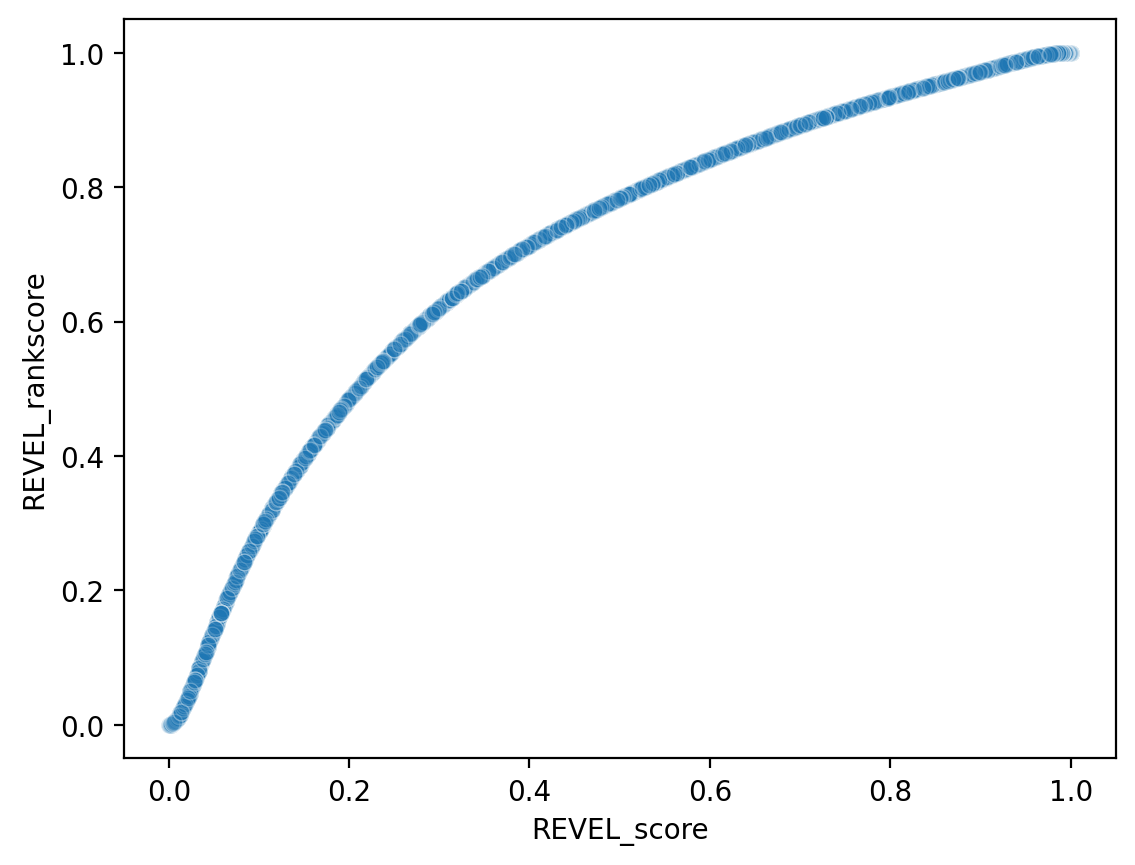

In [50]:
# What's the relationship between rankscore and score?
df_dbnsfp_clean_version["REVEL_rankscore"] = df_dbnsfp_clean_version.apply(lambda row: choose_version(row["REVEL_rankscore"], row["id_index"]), axis=1).replace(".", np.nan).astype(float)
sns.scatterplot(x=df_dbnsfp_clean_version["REVEL_score"].astype(float), y=df_dbnsfp_clean_version["REVEL_rankscore"].astype(float), alpha=0.3)

## Merge models and dbnsfp (can start from here and load clean dbNFSP file)

In [52]:
# Remember to also cast dbNSFP CHROM column to string for merging
df_dbnsfp_clean_version = pd.read_csv(dbnsfp_clean_file, dtype={"#CHROM": str})
print(df_dbnsfp_clean_version["BayesDel_noAF_score"].value_counts(dropna=False))
df_dbnsfp_clean_version.head()

/tmp/ipykernel_155046/3722250284.py:2: DtypeWarning: Columns (47,50,51,52,66,67,68,69,97,100,103,106,118,121,124,127,128,129,131,132,134,136,142,151,153,155,158,161,164,167,170,173,175,177,179,189,190,191,193,194,195,198,199,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,223,224,225,228,229,230,231,234,235,236,237,239,240,241,242,735,752,756,757,781,782,783,784,785,787,788,790,791,792,793,794,795,796,797,798,799,800,801,802,803,804,805,806,807,808,809,811,812,823,824,825,826,827,828,829,830,831,836) have mixed types. Specify dtype option on import or set low_memory=False.
  df_dbnsfp_clean_version = pd.read_csv(dbnsfp_clean_file, dtype={"#CHROM": str})


NaN         97
0.292353     7
0.286511     7
0.552012     6
0.236282     6
            ..
0.309015     1
0.362029     1
0.536941     1
0.583189     1
0.803135     1
Name: BayesDel_noAF_score, Length: 60528, dtype: int64


,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,protein,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,mutant,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,protein_sequence,mutated_sequence,ClinSigSimple,aaref,aaalt,rs_dbSNP,hg19_chr,hg19_pos(1-based),hg18_chr,hg18_pos(1-based),aapos,genename,Ensembl_geneid,Ensembl_transcriptid,Ensembl_proteinid,Uniprot_acc,Uniprot_entry,HGVSc_ANNOVAR,HGVSp_ANNOVAR,HGVSc_snpEff,HGVSp_snpEff,HGVSc_VEP,HGVSp_VEP,APPRIS,GENCODE_basic,TSL,VEP_canonical,cds_strand,refcodon,codonpos,codon_degeneracy,Ancestral_allele,AltaiNeandertal,Denisova,VindijiaNeandertal,ChagyrskayaNeandertal,SIFT_score,SIFT_converted_rankscore,SIFT_pred,SIFT4G_score,SIFT4G_converted_rankscore,SIFT4G_pred,Polyphen2_HDIV_score,Polyphen2_HDIV_rankscore,Polyphen2_HDIV_pred,Polyphen2_HVAR_score,Polyphen2_HVAR_rankscore,Polyphen2_HVAR_pred,LRT_score,LRT_converted_rankscore,LRT_pred,LRT_Omega,MutationTaster_score,MutationTaster_converted_rankscore,MutationTaster_pred,MutationTaster_model,MutationTaster_AAE,MutationAssessor_score,MutationAssessor_rankscore,MutationAssessor_pred,FATHMM_score,FATHMM_converted_rankscore,FATHMM_pred,PROVEAN_score,PROVEAN_converted_rankscore,PROVEAN_pred,VEST4_score,VEST4_rankscore,MetaSVM_score,MetaSVM_rankscore,MetaSVM_pred,MetaLR_score,MetaLR_rankscore,MetaLR_pred,Reliability_index,MetaRNN_score,MetaRNN_rankscore,MetaRNN_pred,M-CAP_score,M-CAP_rankscore,M-CAP_pred,REVEL_score,REVEL_rankscore,MutPred_score,MutPred_rankscore,MutPred_protID,MutPred_AAchange,MutPred_Top5features,MVP_score,MVP_rankscore,gMVP_score,gMVP_rankscore,MPC_score,MPC_rankscore,PrimateAI_score,PrimateAI_rankscore,PrimateAI_pred,DEOGEN2_score,DEOGEN2_rankscore,DEOGEN2_pred,BayesDel_addAF_score,BayesDel_addAF_rankscore,BayesDel_addAF_pred,BayesDel_noAF_score,BayesDel_noAF_rankscore,BayesDel_noAF_pred,ClinPred_score,ClinPred_rankscore,ClinPred_pred,LIST-S2_score,LIST-S2_rankscore,LIST-S2_pred,VARITY_R_score,VARITY_R_rankscore,VARITY_ER_score,VARITY_ER_rankscore,VARITY_R_LOO_score,VARITY_R_LOO_rankscore,VARITY_ER_LOO_score,VARITY_ER_LOO_rankscore,Aloft_Fraction_transcripts_affected,Aloft_prob_Tolerant,Aloft_prob_Recessive,Aloft_prob_Dominant,Aloft_pred,Aloft_Confidence,CADD_raw,CADD_raw_rankscore,CADD_phred,CADD_raw_hg19,CADD_raw_rankscore_hg19,CADD_phred_hg19,DANN_score,DANN_rankscore,fathmm-MKL_coding_score,fathmm-MKL_coding_rankscore,fathmm-MKL_coding_pred,fathmm-MKL_coding_group,fathmm-XF_coding_score,fathmm-XF_coding_rankscore,fathmm-XF_coding_pred,Eigen-raw_coding,Eigen-raw_coding_rankscore,Eigen-phred_coding,Eigen-PC-raw_coding,Eigen-PC-raw_coding_rankscore,Eigen-PC-phred_coding,GenoCanyon_score,GenoCanyon_rankscore,integrated_fitCons_score,integrated_fitCons_rankscore,integrated_confidence_value,GM12878_fitCons_score,GM12878_fitCons_rankscore,GM12878_confidence_value,H1-hESC_fitCons_score,H1-hESC_fitCons_rankscore,H1-hESC_confidence_value,HUVEC_fitCons_score,HUVEC_fitCons_rankscore,HUVEC_confidence_value,LINSIGHT,LINSIGHT_rankscore,GERP++_NR,GERP++_RS,GERP++_RS_rankscore,phyloP100way_vertebrate,phyloP100way_vertebrate_rankscore,phyloP470way_mammalian,phyloP470way_mammalian_rankscore,phyloP17way_primate,phyloP17way_primate_rankscore,phastCons100way_vertebrate,phastCons100way_vertebrate_rankscore,phastCons470way_mammalian,phastCons470way_mammalian_rankscore,phastCons17way_primate,phastCons17way_primate_rankscore,SiPhy_29way_pi,SiPhy_29way_logOdds,SiPhy_29way_logOdds_rankscore,bStatistic,bStatistic_converted_rankscore,1000Gp3_AC,1000Gp3_AF,1000Gp3_AFR_AC,1000Gp3_AFR_AF,1000Gp3_EUR_AC,1000Gp3_EUR_AF,1000Gp3_AMR_AC,1000Gp3_AMR_AF,1000Gp3_EAS_A

In [70]:
"#CHROM	POS	ID	REF	ALT".split("\t") + list(set(df_merged.columns) - set(df_dbnsfp_clean_version.columns))

['#CHROM', 'POS', 'ID', 'REF', 'ALT', 'GEMME', 'TranceptEVE', 'EVE', 'ESM1b']

In [74]:
df_to_merge = df_merged["#CHROM	POS	ID	REF	ALT".split("\t") + list(set(df_merged.columns) - set(df_dbnsfp_clean_version.columns))]
df_models_dbnsfp = df_dbnsfp_clean_version.merge(df_to_merge, on="#CHROM	POS	ID	REF	ALT".split("\t"), how='inner')  # Inner merge results in about 62600 rows vs 63250 rows with outer merge
df_models_dbnsfp

#CHROM        POS       ID REF ALT QUAL FILTER  #Uploaded_variation  \
0          1    1020183   387476   G   C    .   PASS               387476   
1          1    1020297   774056   A   C    .   PASS               774056   
2          1    1022225   243036   G   A    .   PASS               243036   
3          1    1022383   541203   C   G    .   PASS               541203   
4          1    1035307   474141   C   T    .   PASS               474141   
...      ...        ...      ...  ..  ..  ...    ...                  ...   
62687      X  154863151    10315   C   T    .   PASS                10315   
62688      X  154863172  2428622   G   A    .   PASS              2428622   
62689      X  154863214  1330287   T   C    .   PASS              1330287   
62690      X  154863220   627110   A   G    .   PASS               627110   
62691      X  154863223   627109   A   C    .   PASS               627109   

          Location Allele    Gene      Feature Feature_type       Consequence  \
0        1:1020183      C  375790  NM_198576.4   Transcript  missense_variant   
1        1:1020297      C  375790  NM_198576.4   Transcript  missense_variant   
2        1:1022225      A  375790  NM_198576.4   Transcript  missense_variant   
3        1:1022383      G  375790  NM_198576.4   Transcript  missense_variant   
4        1:1035307      T  375790  NM_198576.4   Transcript  missense_variant   
...            ...    ...     ...          ...          ...               ...   
62687  X:154863151      T    2157  NM_019863.3   Transcript  missense_variant   
62688  X:154863172      A    2157  NM_019863.3   Transcript  missense_variant   
62689  X:154863214      C    2157  NM_019863.3   Transcript  missense_variant   
62690  X:154863220      G    2157  NM_019863.3   Transcript  missense_variant   
62691  X:154863223      C    2157  NM_019863.3   Transcript  missense_variant   

       cDNA_position  CDS_position  Protein_position Amino_acids   Codons  \
0                 64            11                 4         R/P  cGg/cCg   
1                178           125                42         E/A  gAg/gCg   
2                279           226                76         G/S  Ggc/Agc   
3                437           384               128         H/Q  caC/caG   
4                547           494               165         P/L  cCt/cTt   
...              ...           ...               ...         ...      ...   
62687            261           101                34         R/H  cGt/cAt   
62688            240            80                27         P/L  cCa/cTa   
62689            198            38                13         N/S  aAt/aGt   
62690            192            32                11         F/S  tTt/tCt   
62691            189            29                10         F/C  tTc/tGc   

      Existing_variation    IMPACT DISTANCE  STRAND FLAGS REFSEQ_MATCH  \
0                      -  MODERATE        -       1     -            -   
1                      -  MODERATE        -       1     -            -   
2                      -  MODERATE        -       1     -            -   
3                      -  MODERATE        -       1     -            -   
4                      -  MODERATE        -       1     -            -   
...                  ...       ...      ...     ...   ...          ...   
62687                  -  MODERATE        -      -1     -            -   
62688                  -  MODERATE        -      -1     -            -   
62689                  -  MODERATE        -      -1     -            -   
62690                  -  MODERATE        -      -1     -            -   
62691                  -  MODERATE        -      -1     -            -   

      REFSEQ_OFFSET GIVEN_REF USED_REF BAM_EDIT                 HGVSc  \
0                 -         G        G        -   NM_198576.4:c.11G>C   
1                 -         A        A        -  NM_198576.4:c.125A>C   
2                 -         G        G        -  NM_198576.4:c.226G>A   
3 

In [75]:
df_models_dbnsfp.to_csv(merged_models_file, index=False)

## Remove duplicates

In [77]:
print("df_clinvar duplicates: ['#CHROM', 'POS', 'REF', 'ALT']:", df_clinvar.duplicated(subset=["#CHROM", "POS", "REF", "ALT"]).sum())
print("dbNSFP duplicates: ['#CHROM', 'POS', 'REF', 'ALT']:", df_dbnsfp.duplicated(subset=["#CHROM", "POS", "REF", "ALT"]).sum()) # 647 rows are originally duplicated
print("dbNSFP after filtering duplicates and mapping: ['#CHROM', 'POS', 'REF', 'ALT']:", df_dbnsfp_clean_version.duplicated(subset=["#CHROM", "POS", "REF", "ALT"]).sum()) # 551 after filtering duplicates and mapping
print("ProteinGym models + dbNSFP duplicates: ['#CHROM', 'POS', 'REF', 'ALT']:", df_models_dbnsfp.duplicated(subset=["#CHROM", "POS", "REF", "ALT"]).sum())
print("ProteinGym models + dbNSFP: ['protein', 'mutant']:", df_models_dbnsfp.duplicated(subset=["protein", "mutant"]).sum()) # 4390 duplicates - that's a ton. We should average this out.

df_clinvar duplicates: ['#CHROM', 'POS', 'REF', 'ALT']: 133
dbNSFP duplicates: ['#CHROM', 'POS', 'REF', 'ALT']: 5
dbNSFP after filtering duplicates and mapping: ['#CHROM', 'POS', 'REF', 'ALT']: 125
ProteinGym models + dbNSFP duplicates: ['#CHROM', 'POS', 'REF', 'ALT']: 600
ProteinGym models + dbNSFP: ['protein', 'mutant']: 478


In [78]:
max_unique_counts = df_models_dbnsfp.groupby(["protein", "mutant"]).nunique().max()
print("Columns with no protein,mutant duplicates: ", max_unique_counts[max_unique_counts == 1])
print("Columns with protein,mutant duplicates: ", max_unique_counts[max_unique_counts > 1])

Columns with no protein,mutant duplicates:  #CHROM                              1
POS                                 1
ID                                  1
REF                                 1
ALT                                 1
                                   ..
ZFIN_zebrafish_phenotype_quality    1
ZFIN_zebrafish_phenotype_tag        1
HGVSp_protein                       1
id_index                            1
max_number_semicolons               1
Length: 681, dtype: int64
Columns with protein,mutant duplicates:  aaref                  2
aaalt                  2
aapos                  2
genename               2
Ensembl_geneid         2
                      ..
MGI_mouse_phenotype    2
GEMME                  6
TranceptEVE            6
EVE                    6
ESM1b                  6
Length: 167, dtype: int64


In [59]:
# This would average over columns like position, and then also throws away the string columns. We don't want that
# df_models_dbnsfp.groupby(["protein", "mutant"]).mean().reset_index()

### Option 1: Drop duplicates in order to easily retain Ensembl and other string columns

In [91]:
# TODO(Lood, 2025): This isn't preferred, because we'd prefer to resolve these 500ish duplicates better
df_models_dbnsfp_dedup = df_models_dbnsfp.drop_duplicates(subset=["protein", "mutant"])

### Option 2: Average over transcripts

In [90]:
# Step 1: Identify data types
# TODO include POS, ID, REF, ALT as strings here, and just choose the first one, or we could concat values together into a longer string (like with the dbNSFP scores)
# numeric_cols = df_models_dbnsfp.select_dtypes(include=['number']).columns
# string_cols = df_models_dbnsfp.select_dtypes(include=['object']).columns

# # Step 2: Deduplicate numeric columns by taking the mean
# numeric_df = df_models_dbnsfp[numeric_cols.to_list() + ["protein", "mutant"]].groupby(["protein", "mutant"]).mean().reset_index()

# # Step 3: Deduplicate string columns by taking unique values
# string_df = df_models_dbnsfp[string_cols].groupby(["protein", "mutant"]).first().reset_index()
# string_df = string_df[[c for c in string_df if c in max_unique_counts[max_unique_counts == 1].index]]  # Only choose values that remain the same (simple)
# assert len(string_df) == len(numeric_df)

# df_models_dbnsfp_averaged = pd.concat([string_df, numeric_df], axis=1)
# df_models_dbnsfp_averaged

In [92]:
df_models_dbnsfp_dedup.to_csv(merged_models_deduplicated, index=False)

## Compute stats (can run notebook from here)

In [99]:
df_models_dbnsfp_averaged = pd.read_csv(merged_models_deduplicated)

/tmp/ipykernel_155046/2675417499.py:1: DtypeWarning: Columns (0,47,50,51,52,66,67,68,69,97,100,103,106,118,121,124,127,128,129,131,132,134,136,142,151,153,155,158,161,164,167,170,173,175,177,179,189,190,191,193,194,195,198,199,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,223,224,225,228,229,230,231,234,235,236,237,239,240,241,242,735,752,756,757,781,782,783,784,785,787,788,790,791,792,793,794,795,796,797,798,799,800,801,802,803,804,805,806,807,808,809,811,812,823,824,825,826,827,828,829,830,831,836) have mixed types. Specify dtype option on import or set low_memory=False.
  df_models_dbnsfp_averaged = pd.read_csv(merged_models_deduplicated)


In [102]:
df_models_dbnsfp_averaged.groupby("protein").apply(lambda group: group["ClinSigSimple"].nunique() == 1).sum()

10

In [108]:
# Quick check, let's make sure that each of the proteins at this point have >1 Pathogenic and >1 Benign
assert df_models_dbnsfp_averaged["ClinSigSimple"].nunique() == 2
# None of the proteins have just one class:
singletons = df_models_dbnsfp_averaged.groupby("protein").apply(lambda group: group["ClinSigSimple"].nunique() == 1)
if singletons.sum() > 0:
    proteins_singletons = singletons[singletons].index
    print(f"{singletons.sum()} proteins have all-pathogenic or all-benign: {proteins_singletons}")
    display(df_models_dbnsfp_averaged[df_models_dbnsfp_averaged["protein"].isin(proteins_singletons)][["protein", "ClinSigSimple"]].value_counts())

10 proteins have all-pathogenic or all-benign: Index(['NP_000393.4', 'NP_000584.3', 'NP_001165806.1', 'NP_001288153.1',
       'NP_001305092.1', 'NP_001340741.2', 'NP_001357524.1', 'NP_001374.4',
       'NP_006339.4', 'NP_071398.5'],
      dtype='object', name='protein')


protein         ClinSigSimple
NP_000584.3     Benign           12
NP_001357524.1  Benign            7
NP_001305092.1  Benign            2
NP_001374.4     Benign            2
NP_000393.4     Pathogenic        1
NP_001165806.1  Benign            1
NP_001288153.1  Pathogenic        1
NP_001340741.2  Pathogenic        1
NP_006339.4     Benign            1
NP_071398.5     Benign            1
dtype: int64

In [110]:
# Let's drop those 10 proteins (TODO(Lood, 2025): The popEVE code has better handling of choosing RefSeq proteins with benign and pathogenic labels)
df_models_dbnsfp_averaged = df_models_dbnsfp_averaged[~df_models_dbnsfp_averaged["protein"].isin(proteins_singletons)]

In [112]:
all_model_cols = db_nsfp_models + list(new_model_cols.values())

#TODO this takes 2 minutes, could speed up by doing column-wise calculations
# Note: Concat RefSeq IDs together, see below:
def get_metrics(group):
    if group["ClinSigSimple"].nunique() == 1:
        return np.nan
    di = {}
    
    if group["protein"].nunique() > 1:
        di["protein"] = ";".join(group["protein"].unique())
    else:
        di["protein"] = group["protein"].unique()[0]
    di["num_variants"] = len(group)  # Useful to compare num_preds to num_variants
    for model in all_model_cols:
        subset = group[group[model].notna()]
        di[f"num_preds_{model}"] = len(subset)
        if len(subset) == 0 or subset["ClinSigSimple"].nunique() == 1:
            di[f"AUC_{model}"] = np.nan
            continue
        scores = subset[model]
        if model in score_directionality_flip or (model in new_model_cols.values() and model != "EVE"):
            scores = -1.0 * scores
        auc = roc_auc_score(y_true=subset["ClinSigBinary"], y_score=scores)
        di[f"AUC_{model}"] = auc
    return pd.Series(di)
        
df_models_dbnsfp_averaged["ClinSigBinary"] = df_models_dbnsfp_averaged["ClinSigSimple"].apply(lambda s: 1 if s == "Pathogenic" else 0)
# df_scores = df_models_dbnsfp_averaged.groupby("protein_sequence").progress_apply(get_metrics)  # Note: Average over protein sequence, not over protein (RefSeq ID)
# Concat together in case of multiple RefSeq IDs - it's a headache to use downstream but will be precise 
#  (rather than arbitrarily choosing one and getting confused later)
# df_scores = df_scores.reset_index().set_index("protein")

from multiprocessing import Pool, cpu_count

def applyParallel(dfGrouped, func):
    with Pool(8) as p:  # cpu_count()
        ret_list = list(tqdm(p.imap(func, [group for name, group in dfGrouped])))
    return ret_list
ret_list = applyParallel(df_models_dbnsfp_averaged.groupby("protein_sequence"), get_metrics)
df_scores = pd.DataFrame.from_records(ret_list)
df_scores

0it [00:00, ?it/s]

,protein,num_variants,num_preds_MetaRNN_score,AUC_MetaRNN_score,num_preds_SIFT4G_score,AUC_SIFT4G_score,num_preds_REVEL_score,AUC_REVEL_score,num_preds_BayesDel_addAF_score,AUC_BayesDel_addAF_score,num_preds_BayesDel_noAF_score,AUC_BayesDel_noAF_score,num_preds_PrimateAI_score,AUC_PrimateAI_score,num_preds_ClinPred_score,AUC_ClinPred_score,num_preds_VARITY_R_LOO_score,AUC_VARITY_R_LOO_score,num_preds_VARITY_ER_LOO_score,AUC_VARITY_ER_LOO_score,num_preds_gMVP_score,AUC_gMVP_score,num_preds_VEST4_score,AUC_VEST4_score,num_preds_CADD_phred,AUC_CADD_phred,num_preds_Polyphen2_HDIV_score,AUC_Polyphen2_HDIV_score,num_preds_Polyphen2_HVAR_score,AUC_Polyphen2_HVAR_score,num_preds_DEOGEN2_score,AUC_DEOGEN2_score,num_preds_SIFT_score,AUC_SIFT_score,num_preds_PROVEAN_score,AUC_PROVEAN_score,num_preds_MutationAssessor_score,AUC_MutationAssessor_score,num_preds_MPC_score,AUC_MPC_score,num_preds_MutPred_score,AUC_MutPred_score,num_preds_LIST-S2_score,AUC_LIST-S2_score,num_preds_DANN_score,AUC_DANN_score,num_preds_LRT_score,AUC_LRT_score,num_preds_FATHMM_score,AUC_FATHMM_score,num_preds_MutationTaster_converted_rankscore,AUC_MutationTaster_converted_rankscore,num_preds_ESM1b,AUC_ESM1b,num_preds_EVE,AUC_EVE,num_preds_TranceptEVE,AUC_TranceptEVE,num_preds_GEMME,AUC_GEMME
0,NP_001291646.4,149,143,1.000000,143,1.000000,143,0.992958,143,1.000000,143,0.950704,140,0.942446,143,1.000000,143,1.000000,143,1.000000,143,1.000000,143,1.000000,143,1.000000,143,0.992958,143,0.992958,143,1.000000,143,1.000000,143,1.000000,140,1.000000,140,1.000000,140,NaN,143,0.915493,143,0.978873,143,0.978873,143,0.690141,143,0.985915,149,0.997988,149,0.884306,149,0.979879,149,0.998994
1,NP_001104262.1,197,197,0.976905,197,0.707216,197,0.953757,197,0.960196,197,0.934972,197,0.946254,197,0.986484,0,NaN,0,NaN,197,0.971903,197,0.932631,197,0.933642,197,0.869519,197,0.902778,0,NaN,197,0.817582,197,0.907993,0,NaN,0,NaN,2,1.000000,197,0.805396,197,0.919221,197,0.901181,197,0.930609,197,0.841156,197,0.915390,197,0.931247,197,0.955407,197,0.943487
2,NP_004357.3,24,24,1.000000,24,0.887500,24,0.975000,24,1.000000,24,0.962500,24,1.000000,24,1.000000,24,0.950000,24,0.962500,24,0.987500,24,0.962500,24,0.950000,24,0.950000,24,0.925000,24,1.000000,24,0.925000,24,0.887500,24,0.950000,24,0.912500,9,1.000000,24,0.900000,24,0.950000,24,0.925000,24,0.875000,24,0.600000,24,0.950000,24,1.000000,24,1.000000,24,1.000000
3,NP_004270.2,7,7,1.000000,7,1.000000,7,1.000000,7,1.000000,7,1.000000,7,1.000000,7,1.000000,7,1.000000,7,1.000000,7,1.000000,7,1.000000,7,1.000000,7,1.000000,7,1.000000,7,1.000000,7,1.000000,7,1.000000,7,1.000000,7,1.000000,1,NaN,7,1.000000,7,1.000000,7,0.833333,7,1.000000,7,0.916667,7,1.000000,7,1.000000,7,1.000000,7,1.000000
4,NP_055134.2,16,16,0.928571,16,0.107143,16,0.392857,16,0.785714,16,0.428571,16,0.607143,16,0.892857,16,0.500000,16,0.464286,16,0.500000,16,0.607143,16,0.321429,16,0.357143,16,0.464286,16,0.178571,16,0.107143,16,0.428571,16,0.428571,0,NaN,9,0.428571,16,0.285714,16,0.357143,16,0.750000,16,0.071429,16,0.625000,16,0.678571,16,0.428571,16,0.464286,16,0.464286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2498,NP_065069.1,3,3,0.500000,3,0.500000,3,0.500000,3,1.000000,3,1.000000,3,0.500000,3,0.500000,3,0.500000,3,0.500000,3,0.500000,3,0.500000,3,1.000000,3,0.500000,3,0.500000,3,0.500000,3,0.500000,3,0.500000,3,0.500000,3,0.500000,2,0.000000,0,NaN,3,0.500000,3,0.750000,0,NaN,3,0.750000,3,1.000000,3,0.500000,3,1.000000,3,1.000000
2499,NP_000162.2,37,37,1.000000,37,0.980769,37,1.000000,37,1.000000,37,0.983974,37,0.820513,37,1.000000,0,NaN,0,NaN,0,NaN,37,0.990385,37,0.959936,37,0.846154,37,0.894231,0,NaN,37,0.985577,37,0.977564,28,1.000000,0,NaN,20,1.000000,37,0.926282,37,0.817308,37,0.722756,37,0.729167,37,0.775641,37,0.993590,37,1.000000,37,1.000000,37,1.000000
2500,NP_00

# Check missing predictions

Is it possible that some proteins don't have both pathogenic and benign? (necessary for AUC)

In [114]:
df_scores[df_scores[f'num_preds_{model}'] == 0]

,protein,num_variants,num_preds_MetaRNN_score,AUC_MetaRNN_score,num_preds_SIFT4G_score,AUC_SIFT4G_score,num_preds_REVEL_score,AUC_REVEL_score,num_preds_BayesDel_addAF_score,AUC_BayesDel_addAF_score,num_preds_BayesDel_noAF_score,AUC_BayesDel_noAF_score,num_preds_PrimateAI_score,AUC_PrimateAI_score,num_preds_ClinPred_score,AUC_ClinPred_score,num_preds_VARITY_R_LOO_score,AUC_VARITY_R_LOO_score,num_preds_VARITY_ER_LOO_score,AUC_VARITY_ER_LOO_score,num_preds_gMVP_score,AUC_gMVP_score,num_preds_VEST4_score,AUC_VEST4_score,num_preds_CADD_phred,AUC_CADD_phred,num_preds_Polyphen2_HDIV_score,AUC_Polyphen2_HDIV_score,num_preds_Polyphen2_HVAR_score,AUC_Polyphen2_HVAR_score,num_preds_DEOGEN2_score,AUC_DEOGEN2_score,num_preds_SIFT_score,AUC_SIFT_score,num_preds_PROVEAN_score,AUC_PROVEAN_score,num_preds_MutationAssessor_score,AUC_MutationAssessor_score,num_preds_MPC_score,AUC_MPC_score,num_preds_MutPred_score,AUC_MutPred_score,num_preds_LIST-S2_score,AUC_LIST-S2_score,num_preds_DANN_score,AUC_DANN_score,num_preds_LRT_score,AUC_LRT_score,num_preds_FATHMM_score,AUC_FATHMM_score,num_preds_MutationTaster_converted_rankscore,AUC_MutationTaster_converted_rankscore,num_preds_ESM1b,AUC_ESM1b,num_preds_EVE,AUC_EVE,num_preds_TranceptEVE,AUC_TranceptEVE,num_preds_GEMME,AUC_GEMME
665,NP_057288.1,15,15,0.928571,15,1.000000,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,15,1.000000,15,1.000000,15,1.000000,0,NaN,0,NaN,15,0.928571,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,15,0.928571,0,NaN,0,NaN,15,0.428571,0,NaN,15,0.857143,15,0.928571,15,0.928571,15,0.928571
1105,NP_998818.1,10,10,1.000000,10,1.000000,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,10,1.000000,10,1.000000,10,0.952381,0,NaN,0,NaN,10,1.000000,10,1.0,10,1.0,0,NaN,0,NaN,0,NaN,10,0.714286,0,NaN,0,NaN,10,0.809524,0,NaN,10,1.000000,10,1.000000,10,1.000000,10,1.000000
1236,NP_653200.2,5,5,1.000000,5,1.000000,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,5,1.000000,5,1.000000,5,1.000000,0,NaN,0,NaN,5,1.000000,5,1.0,5,1.0,0,NaN,0,NaN,0,NaN,5,1.000000,0,NaN,0,NaN,5,0.666667,0,NaN,5,1.000000,5,1.000000,5,1.000000,5,1.000000
1601,NP_002891.1,12,12,0.888889,12,0.777778,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,12,0.851852,12,0.814815,12,0.814815,0,NaN,0,NaN,12,0.740741,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,12,0.518519,0,NaN,0,NaN,12,0.518519,0,NaN,12,0.592593,12,0.703704,12,0.777778,12,0.629630
2128,NP_001171818.1,3,3,1.000000,3,1.000000,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,3,1.000000,3,1.000000,0,NaN,0,NaN,3,1.000000,3,1.0,3,1.0,0,NaN,0,NaN,0,NaN,3,1.000000,0,NaN,0,NaN,3,1.000000,0,NaN,3,1.000000,3,1.000000,3,1.000000,3,1.000000


In [116]:
for model in ["EVE", "TranceptEVE", "ESM1b", "BayesDel_noAF_score"]:  # BayesDel_noAF_score and CADD seem to have the fewest missing values in the total variants df (only missing ~5 proteins)
    print(f"{model} number of proteins with no predictions: {(df_scores[f'num_preds_{model}'] == 0).sum()}/{len(df_scores)}")
    if (df_scores[f'num_preds_{model}'] == 0).sum() > 0:
        print(f"Example: {df_scores[df_scores[f'num_preds_{model}'] == 0]['protein'].iloc[0]}")

EVE number of proteins with no predictions: 0/2503
TranceptEVE number of proteins with no predictions: 0/2503
ESM1b number of proteins with no predictions: 0/2503
BayesDel_noAF_score number of proteins with no predictions: 5/2503
Example: NP_057288.1


In [117]:
# Check worst coverage
df_scores[[c for c in df_scores.columns if c.startswith("num_preds")]].apply(lambda col: col == df_scores["num_variants"]).sum().sort_values(ascending=True)

num_preds_MutPred_score                          103
num_preds_MPC_score                             1482
num_preds_gMVP_score                            1555
num_preds_VARITY_R_LOO_score                    1768
num_preds_VARITY_ER_LOO_score                   1768
num_preds_LIST-S2_score                         1802
num_preds_MutationAssessor_score                1826
num_preds_DEOGEN2_score                         1861
num_preds_Polyphen2_HDIV_score                  1965
num_preds_Polyphen2_HVAR_score                  1965
num_preds_FATHMM_score                          2090
num_preds_SIFT_score                            2105
num_preds_REVEL_score                           2113
num_preds_PROVEAN_score                         2121
num_preds_LRT_score                             2121
num_preds_VEST4_score                           2223
num_preds_SIFT4G_score                          2302
num_preds_PrimateAI_score                       2353
num_preds_MutationTaster_converted_rankscore  

In [118]:
df_scores.to_csv(clinical_scores_file, index=False)

In [119]:
# df_scores = pd.read_csv(clinical_scores_file)
# Get overall stats
print(df_scores[[c for c in df_scores.columns if c.startswith("AUC")]].mean().sort_values(ascending=False))
print("\nAverage number of predictions per gene")
print(df_scores[[c for c in df_scores.columns if not c.startswith("AUC")]].mean().sort_values(ascending=False))
print("\nNumber of genes with AUC values") # Note: MutPred only has 102 genes with AUC values
print(df_scores[[c for c in df_scores.columns if c.startswith("AUC")]].notna().sum().sort_values(ascending=False))
print("\nNumber of genes with >0 predictions")
print((df_scores[[c for c in df_scores.columns if c.startswith("num_preds")]] > 0).sum().sort_values(ascending=False))
print("\nNumber of genes with all variants scored")
print(df_scores[[c for c in df_scores.columns if c.startswith("num_preds")]].apply(lambda col: col == df_scores["num_variants"]).sum().sort_values(ascending=False))

AUC_ClinPred_score                        0.980828
AUC_MetaRNN_score                         0.977010
AUC_BayesDel_addAF_score                  0.972033
AUC_VEST4_score                           0.929292
AUC_REVEL_score                           0.927510
AUC_BayesDel_noAF_score                   0.925143
AUC_VARITY_R_LOO_score                    0.920683
AUC_TranceptEVE                           0.919443
AUC_GEMME                                 0.919022
AUC_VARITY_ER_LOO_score                   0.917633
AUC_gMVP_score                            0.914467
AUC_EVE                                   0.913776
AUC_CADD_phred                            0.904796
AUC_Polyphen2_HVAR_score                  0.895849
AUC_DEOGEN2_score                         0.893759
AUC_ESM1b                                 0.891764
AUC_PROVEAN_score                         0.885741
AUC_MPC_score                             0.880608
AUC_Polyphen2_HDIV_score                  0.879407
AUC_SIFT_score                 

/tmp/ipykernel_155046/2372446747.py:5: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  print(df_scores[[c for c in df_scores.columns if not c.startswith("AUC")]].mean().sort_values(ascending=False))


## Clinical Ranking Table

In [120]:
model_type = {'TranceptEVE': 'Unsupervised',
    'EVE': 'Unsupervised',
    'ESM-1b': 'Unsupervised',
    'DEOGEN2': 'Supervised',
    'MutationAssessor': 'Unsupervised',
    'PROVEAN': 'Unsupervised',
    'SIFT': 'Unsupervised',
    'MutPred': 'Unsupervised',
    'CADD': 'Supervised',
    'MPC': 'Supervised',
    'PrimateAI': 'Unsupervised',
    'Polyphen2_HVAR': 'Supervised',
    'Polyphen2_HDIV': 'Supervised',
    'LIST-S2': 'Unsupervised',
    'FATHMM': 'Supervised',
    'LRT': 'Unsupervised',
    'DANN': 'Supervised',
    'MutationTaster': 'Supervised',
    "GEMME": "Unsupervised",
    # New models
    "ClinPred": "Supervised",
    "BayesDel (addAF)": "Supervised",
    "BayesDel (noAF)": "Supervised",
    "VARITY (ER)": "Supervised",
    "VARITY (R)": "Supervised",
    "REVEL": "Supervised",
    "PolyPhen2 (HDIV)": "Supervised",
    "PolyPhen2 (HVAR)": "Supervised",
    "gMVP": "Supervised",
    "VEST4": "Supervised",
    "MetaRNN": "Supervised",
    "SIFT4G": "Unsupervised",
}
model_rename = {
    "BayesDel_addAF": "BayesDel (addAF)",
    "BayesDel_noAF": "BayesDel (noAF)",
    "Polyphen2_HDIV": "PolyPhen2 (HDIV)",
    "Polyphen2_HVAR": "PolyPhen2 (HVAR)",
    "VARITY_ER_LOO": "VARITY (ER)",
    "VARITY_R_LOO": "VARITY (R)",
    "CADD_phred": "CADD",
    "TranceptEVE_L": "TranceptEVE",
    "ESM1b": "ESM-1b"
}

In [121]:
# Exclude some models
def latex_format(row):
    # Ranking, Model, Type, AUC
    return f"{row['ranking']} & {row['model']} & {row['model_type']} & {row['AUC']:.3f} \\\\"
df_ranking = df_scores[[c for c in df_scores.columns if c.startswith("AUC")]].mean().sort_values(ascending=False).copy()
df_ranking.name = "AUC"
df_ranking = df_ranking.reset_index(drop=False).rename(columns={"index": "model"})
df_ranking = df_ranking.reset_index(drop=False).rename(columns={"index": "ranking"})
df_ranking["ranking"] += 1
# Clean up model name
df_ranking["model"] = df_ranking["model"].apply(lambda s: s.strip().replace("AUC_", "").replace("_score", "").replace("_converted_rankscore", ""))
df_ranking["model"] = df_ranking["model"].apply(lambda s: model_rename.get(s, s))
# Add supervised / unsupervised
df_ranking["model_type"] = df_ranking["model"].apply(lambda s: model_type[s])
display(df_ranking)
df_ranking.round(3).to_csv("../2023_12_05_clinical_subs_AUC_ranking.csv",index=False)
# Get LaTex version
print("\n".join(df_ranking.apply(latex_format, axis=1)))

,ranking,model,AUC,model_type
0,1,ClinPred,0.980828,Supervised
1,2,MetaRNN,0.977010,Supervised
2,3,BayesDel (addAF),0.972033,Supervised
3,4,VEST4,0.929292,Supervised
4,5,REVEL,0.927510,Supervised
5,6,BayesDel (noAF),0.925143,Supervised
6,7,VARITY (R),0.920683,Supervised
7,8,TranceptEVE,0.919443,Unsupervised
8,9,GEMME,0.919022,Unsupervised
9,10,VARITY (ER),0.917633,Supervised


1 & ClinPred & Supervised & 0.981 \\
2 & MetaRNN & Supervised & 0.977 \\
3 & BayesDel (addAF) & Supervised & 0.972 \\
4 & VEST4 & Supervised & 0.929 \\
5 & REVEL & Supervised & 0.928 \\
6 & BayesDel (noAF) & Supervised & 0.925 \\
7 & VARITY (R) & Supervised & 0.921 \\
8 & TranceptEVE & Unsupervised & 0.919 \\
9 & GEMME & Unsupervised & 0.919 \\
10 & VARITY (ER) & Supervised & 0.918 \\
11 & gMVP & Supervised & 0.914 \\
12 & EVE & Unsupervised & 0.914 \\
13 & CADD & Supervised & 0.905 \\
14 & PolyPhen2 (HVAR) & Supervised & 0.896 \\
15 & DEOGEN2 & Supervised & 0.894 \\
16 & ESM-1b & Unsupervised & 0.892 \\
17 & PROVEAN & Unsupervised & 0.886 \\
18 & MPC & Supervised & 0.881 \\
19 & PolyPhen2 (HDIV) & Supervised & 0.879 \\
20 & SIFT & Unsupervised & 0.878 \\
21 & SIFT4G & Unsupervised & 0.877 \\
22 & MutationAssessor & Unsupervised & 0.877 \\
23 & MutPred & Unsupervised & 0.875 \\
24 & PrimateAI & Unsupervised & 0.855 \\
25 & LIST-S2 & Unsupervised & 0.842 \\
26 & MutationTaster & Supervi

In [ ]:
# Write out to file
# clinical_rankings_file

In [ ]:
import shutil
shutil.copy2(merged_models_deduplicated, "/n/www/marks.hms.harvard.edu/docroot/proteingym/other/")